# Analisis de dagtos II
### Pablo Salvagni

### Consigna
#### Actividad 2. Interpretabilidad de modelos
Descargar el dataset de salarios en data science disponible en Kaggle:
https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023 y luego aplicar los siguientes pasos:

#### Preparar los datos
Dividir el dataset en 2 períodos:
- Referencia: años 2020-2021
- Actual: años 2022-2023

#### Calidad y drift
- a. Elegir 3-4 variables relevantes (por ej. salary_in_usd, experience_level,
remote_ratio, company_size) y aplicar al menos 3 chequeos de calidad a elección.
- b. Sobre las mismas variables, calcular PSI comparando la distribución de referencia
vs. la actual.
- c. Para cada variable, indicar si hay drift y a qué tipo podría corresponder. Establecer
un umbral y justificar la conclusión a partir del valor de PSI y de dicho umbral.
- d. Con el modelo entrenado en la Actividad 1: si detectaron drift, qué estrategia de las
vistas en clase (reentrenamiento, feature engineering, ensamble) aplicarías?
Justificar la elección.

#### Detección de anomalías
- a. Aplicar Isolation Forest y LOF sobre el dataset, usando variables relevantes.
- b. Identificar al menos un registro marcado como anómalo por alguno de los dos
métodos.
- c. Para ese registro: ¿es un outlier univariado o multivariado? Justificar mirando los
valores reales del registro.
- d. ¿Isolation Forest y LOF coinciden en marcarlo como anómalo? Si no coinciden, ¿a
qué se debe la diferencia (repasar la lógica de cada uno)?


In [141]:
import pandas as pd
import matplotlib.pyplot as plt

# Preparación y entrenamiento ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Interpretabilidad -------------------------------------
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE

#### 1. Importación de dataset      

In [142]:
# Cargar el dataset desde archivo local
df = pd.read_csv('dataset/ds_salaries.csv')

# Mostrar las primeras filas para confirmar la carga
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


#### 2. Realizar un mini EDA 


In [143]:
# Verificamos la estructura y si hay nulos
print(df.info())

# Resumen estadistico de variables numricas y categoricas
display(df.describe())
display(df.describe(include='object'))

print("--------------------------------")
print("------------ NULOS -------------")
print("--------------------------------")

# chequear nulos por cada columna
valores_nulos_por_columna = df.isnull().sum()
print(valores_nulos_por_columna)

# chequear nulos por cada fila
valores_nulos_por_fila = df.isnull().sum(axis=1)
print(valores_nulos_por_fila)


<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB
None


,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


--------------------------------
------------ NULOS -------------
--------------------------------
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64
0       0
1       0
2       0
3       0
4       0
       ..
3750    0
3751    0
3752    0
3753    0
3754    0
Length: 3755, dtype: int64


In [144]:
# Dividir el dataset en 2 períodos:
# - Referencia: años 2020-2021
# - Actual: años 2022-2023

# Filtramos los datos para cada período
df_referencia = df[df['work_year'].isin([2020, 2021])]
df_actual = df[df['work_year'].isin([2022, 2023])]

# Guardamos los datasets filtrados
df_referencia.to_csv('dataset/ds_salaries_referencia.csv', index=False)
df_actual.to_csv('dataset/ds_salaries_actual.csv', index=False)

# print(df_referencia.head())
# print(df_actual.head())
print(len(df_referencia), len(df_actual))

306 3449


#### Calidad y drift
a. Elegir 3-4 variables relevantes (por ej. salary_in_usd, experience_level,
remote_ratio, company_size) y aplicar al menos 3 chequeos de calidad a elección.


In [145]:
import great_expectations as gx

# Definimos el contexto de Great Expectations
context = gx.get_context()
data_source = context.data_sources.add_pandas("pandas_source") # Le aviso que voy a trabajar con formato de pandas
data_asset = data_source.add_dataframe_asset(name="df_assets") # Defino un asset - un dataset
batch_definition = data_asset.add_batch_definition_whole_dataframe("batch_def") # Cada vez que se pida un batch de este dataset, que se tome todo el dataset
batch = batch_definition.get_batch(batch_parameters={"dataframe": df}) # Crear el batch

In [146]:
#1. Completitud
cols = ["salary_in_usd", "experience_level", "remote_ratio", "company_size"]

print("Nulos:")
print((df[cols].isna().mean() * 100).round(2))
for col in cols:
    resultado = batch.validate(
        gx.expectations.ExpectColumnValuesToNotBeNull(column=col, mostly=1.0)
    )
    print(f"Completitud ({col}): {'OK' if resultado.success else 'FAIL'}")


Nulos:
salary_in_usd       0.0
experience_level    0.0
remote_ratio        0.0
company_size        0.0
dtype: float64


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (salary_in_usd): OK


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (experience_level): OK


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (remote_ratio): OK


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Completitud (company_size): OK


In [147]:
# 2. Validez > rango y categorías permitidas

resultado_rango = batch.validate(
    gx.expectations.ExpectColumnValuesToBeBetween(
        column="salary_in_usd", min_value=1, max_value=500000
    )
)
print(
    f"Validez (salary_in_usd en rango): {'OK' if resultado_rango.success else 'FAIL'} "
    f"({resultado_rango.result.get('unexpected_count', 0)} fuera de rango)"
)

resultado_exp = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="experience_level", value_set=["EN", "MI", "SE", "EX"]
    )
)
print(f"Validez (experience_level): {'OK' if resultado_exp.success else 'FAIL'}")

resultado_remote = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="remote_ratio", value_set=[0, 50, 100]
    )
)
print(f"Validez (remote_ratio): {'OK' if resultado_remote.success else 'FAIL'}")

resultado_size = batch.validate(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="company_size", value_set=["S", "M", "L"]
    )
)
print(f"Validez (company_size): {'OK' if resultado_size.success else 'FAIL'}")

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (salary_in_usd en rango): OK (0 fuera de rango)


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (experience_level): OK


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (remote_ratio): OK


Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Validez (company_size): OK


In [148]:
# 3. Unicidad
resultado_unicidad = batch.validate(
    gx.expectations.ExpectCompoundColumnsToBeUnique(
        column_list=[
            "work_year", "experience_level", "employment_type", "job_title",
            "salary", "salary_currency", "salary_in_usd", "employee_residence",
            "remote_ratio", "company_location", "company_size",
        ]
    )
)
print(
    f"Unicidad: {'OK' if resultado_unicidad.success else 'FAIL'} "
    f"({resultado_unicidad.result.get('unexpected_count', 0)} duplicados)"
)
print("duplicated().sum() =", df.duplicated().sum())

Calculating Metrics:   0%|          | 0/9 [00:00<?, ?it/s]

Unicidad: FAIL (1715 duplicados)
duplicated().sum() = 1171


In [149]:
# 4. Consistencia  si es USD, salary debe igualar salary_in_usd

df_cons = df.copy()
df_cons["diff_usd"] = df_cons["salary"] - df_cons["salary_in_usd"]

# solo tiene sentido el check en filas USD; en el resto ponemos 0 para no romper el batch
df_cons.loc[df_cons["salary_currency"] != "USD", "diff_usd"] = 0
data_asset_2 = data_source.add_dataframe_asset(name="df_consistencia")
batch_def_2 = data_asset_2.add_batch_definition_whole_dataframe("batch_def_2")
batch_2 = batch_def_2.get_batch(batch_parameters={"dataframe": df_cons})
resultado_cons = batch_2.validate(
    gx.expectations.ExpectColumnValuesToBeBetween(
        column="diff_usd", min_value=0, max_value=0, mostly=0.99
    )
)
print(
    f"Consistencia (USD: salary == salary_in_usd): "
    f"{'OK' if resultado_cons.success else 'FAIL'}"
)

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Consistencia (USD: salary == salary_in_usd): OK


#### Conclusiones preliminares
1. **Completitud**: Mostro 0.0% sobres las 4 columnas elegidas, confirmando que en el bloque elegido no hay nulos.

2. **Validez**:todos valores validados dieron **OK** segun lo esperado. Si los margenes se achican, van creciendo la cantidad de de fuera de rango, siendo 1-75000 el valor que deja fuera a casi el 80% de los casos. 

3. **Unicidad**: En este caso la **FAIL**, lo cual pareceria correcto, ya que se identifican filas duclicadas con mismo año, job, sueldo, etc.. 

4. **Consistencia**: en las filas de USD, ``salary``- ``salary_in_usd``da 0, lo cual tiene sentido ya que si la moneda ya es el USD, los montos locales y el convertido coinciden. 

b. Sobre las mismas variables, calcular PSI comparando la distribución de referencia
vs. la actual.

In [166]:
from evidently import Report, Dataset, DataDefinition
from evidently.metrics import ValueDrift

cols = ["salary_in_usd", "experience_level", "remote_ratio", "company_size"]

ds_reference = Dataset.from_pandas( df_referencia[cols], data_definition=DataDefinition())
ds_actual = Dataset.from_pandas( df_actual[cols], data_definition=DataDefinition())

report_psi = Report(metrics=[
    ValueDrift(column=c, method="psi") for c in cols
])

# Actual primero, referencia segundo (igual que en clase)
resultado_psi = report_psi.run(ds_actual, ds_reference)

# PSI compara dis. actual vs refferencia. Evidently marca drift si PSI > 0.1
# Convencion: <0.10 nada, 0.10-0.25 moderado, >0.25 fuerte
# guardo variables para usar en tabla de resultados
psi_salary_in_usd = resultado_psi.dict()["metrics"][0]["value"]
psi_experience_level = resultado_psi.dict()["metrics"][1]["value"]
psi_remote_ratio = resultado_psi.dict()["metrics"][2]["value"]
psi_company_size = resultado_psi.dict()["metrics"][3]["value"]

print("PSI de referencia (2020-2021) vs actual (2022-2023)")
print("---------------------------------------------------")
for m in resultado_psi.dict()["metrics"]:
    print(m["metric_name"], "->", round(m["value"], 4))



PSI de referencia (2020-2021) vs actual (2022-2023)
---------------------------------------------------
ValueDrift(column=salary_in_usd,method=psi,threshold=0.1) -> 0.9204
ValueDrift(column=experience_level,method=psi,threshold=0.1) -> 0.7417
ValueDrift(column=remote_ratio,method=psi,threshold=0.1) -> 1.1914
ValueDrift(column=company_size,method=psi,threshold=0.1) -> 2.1981


In [167]:
# Distribuciones de referencia vs actual
for col in cols: 
    print(f"Distribución de {col} en referencia:")
    print(f"\n=== {col} ===")
    # value_counts: sirve en categoricas (experience, remote, size)
    print("ref:\n", df_referencia[col].value_counts(normalize=True).round(3).head())
    # en salary_in_usd (continua) no muestra el corrimiento; eso va en el KDE
    print("act:\n", df_actual[col].value_counts(normalize=True).round(3).head())



Distribución de salary_in_usd en referencia:

=== salary_in_usd ===
ref:
 salary_in_usd
150000    0.026
100000    0.023
200000    0.020
20000     0.016
50000     0.016
Name: proportion, dtype: float64
act:
 salary_in_usd
100000    0.027
150000    0.026
120000    0.025
130000    0.023
160000    0.023
Name: proportion, dtype: float64
Distribución de experience_level en referencia:

=== experience_level ===
ref:
 experience_level
MI    0.405
SE    0.297
EN    0.255
EX    0.042
Name: proportion, dtype: float64
act:
 experience_level
SE    0.703
MI    0.197
EN    0.070
EX    0.029
Name: proportion, dtype: float64
Distribución de remote_ratio en referencia:

=== remote_ratio ===
ref:
 remote_ratio
100    0.520
50     0.317
0      0.163
Name: proportion, dtype: float64
act:
 remote_ratio
0      0.543
100    0.430
50     0.027
Name: proportion, dtype: float64
Distribución de company_size en referencia:

=== company_size ===
ref:
 company_size
L    0.529
M    0.235
S    0.235
Name: proportion, 

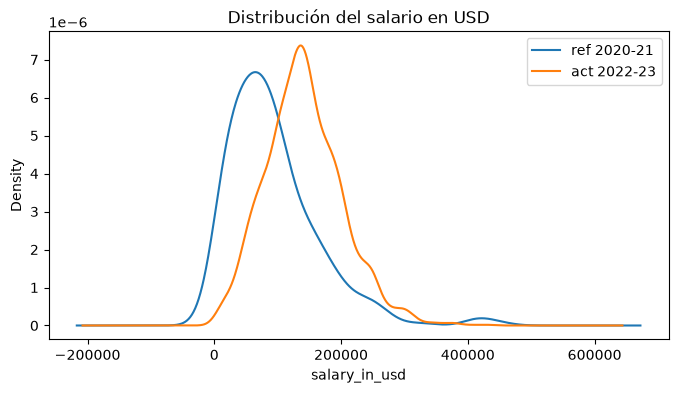

In [168]:
# KDE del target: si la curva actual se corre a la derecha, confirma PSI alto
fig, ax = plt.subplots(figsize=(8, 4))
df_referencia["salary_in_usd"].plot.kde(ax=ax, label="ref 2020-21")
df_actual["salary_in_usd"].plot.kde(ax=ax, label="act 2022-23")
ax.set_xlabel("salary_in_usd")
ax.legend()
ax.set_title("Distribución del salario en USD")
plt.show()


- c. Para cada variable, indicar si hay drift y a qué tipo podría corresponder. Establecer
un umbral y justificar la conclusión a partir del valor de PSI y de dicho umbral.


In [169]:
# Umbral de alerta = 0.10 (default de Evidently en clase).
# Ademas: 0.10-0.25 moderado, > 0.25 fuerte (convencion habitual de PSI) 
# Definir umbral de alerta:
UMBRAL = 0.10

# Tomo  los valores de PSI para cada variable
psi = {
    "salary_in_usd": psi_salary_in_usd,
    "experience_level": psi_experience_level,
    "remote_ratio": psi_remote_ratio,
    "company_size": psi_company_size,
}

# Definir tipo de drift segun el rol en el modelo limpio:
# features -> covariate shift
# target -> label shift
tipos = {
    "salary_in_usd": "label shift",
    "experience_level": "covariate shift",
    "remote_ratio": "covariate shift",
    "company_size": "covariate shift",
}

# Tabla de resultados
filas = []
for col, val in psi.items():
    if val < UMBRAL:
        nivel = "sin drift"
    elif val < 0.25:
        nivel = "moderado"
    else:
        nivel = "fuerte"
    filas.append({
        "variable": col,
        "PSI": val,
        "hay_drift": val >= UMBRAL,
        "nivel": nivel,
        "tipo": tipos[col],
    })

display(pd.DataFrame(filas))

,variable,PSI,hay_drift,nivel,tipo
0,salary_in_usd,0.920436,True,fuerte,label shift
1,experience_level,0.741723,True,fuerte,covariate shift
2,remote_ratio,1.191421,True,fuerte,covariate shift
3,company_size,2.198147,True,fuerte,covariate shift


### Conclusion de PSI

Umbral: **PSI >= 0.10** = hay drift (Evidently). **> 0.25** = fuerte.

Las 4 variables superan el 0.25, por lo que podemos ver que hay un **drift** fuerte en **todos** los casos.

- `experience_level` (0.74) — covariate shift. Feature del TP1. SE 30% -> 70%, EN 25% -> 7%.
- `salary_in_usd` (0.92) — label shift. Es el **target** del TP1. El KDE se corre a la derecha (~94k → ~141k).
- `remote_ratio` (1.19) — covariate shift. Feature. El hibrido 50% casi desaparece (32% -> 3%).
- `company_size` (2.20) — covariate shift. Feature. Empresas M 24% -> 89%.

**Contra del PSI:** si un **bin** queda en 0% en referencia o en actual, `ln(df_actual/df_referencia)` explota y el PSI puede ir a **infinito**. Es la unica contra seria de la metrica. Aca no paso: las **categorias de experience, remote y size** aparecen en los dos periodos, por eso los valores son finitos (el maximo es 2.20, no inf).

**Concept drift:** el PSI no lo prueba. Eso seria un cambio en P(y|x), no en la dist. de una columna.
Nota: parte del salto de salario puede venir del mix (mas SE, mas empresas M), pero `salary_in_usd` igual se clasifica como label shift porque es el target.




------


d. Con el modelo entrenado en la Actividad 1: si detectaron drift, qué estrategia de las
vistas en clase (reentrenamiento, feature engineering, ensamble) aplicarías?
Justificar la elección.

### Estrategia frente al **drift**

Hay **covariate shift** (experience, remote, size) **y** label shift (salario). Es una mezcla bastante comun en este mercado: cambio el perfil de quien trabaja (mas seniors, mas empresas M, menos hibrido post pandemia) y ademas subio el nivel de sueldos.

Elegiria **reentrenamiento** del modelo limpio de [la Actividad 1](../tp1/tp1.ipynb) (sin `salary` ni `salary_currency`), usando datos de 2022-2023 o una ventana reciente.

- Ese RF se entreno con un split aleatorio de **todos** los años. El PSI muestra que 2022-2023 ya no tiene el mismo P(x) ni el mismo P(y) que 2020-2021 (306 vs 3449 filas, otro mix). Seguir usandolo asume que esas dist. no cambiaron.
- **Feature engineering** ayuda si un feature se volvio inutil o hay que crear otro. No alcanzaria cuando se movio el target y casi todas las features.
- **Ensamble** (modelo viejo + modelo nuevo) seria habitual en produccion para no tirar el historico de golpe. El tramo viejo es chico y poco representativo: mezclarlo sumaria ruido. Con un drift mas suave a futuro, creeria que si tendria sentido ensamblar modelos.

Reentrenaria con datos actuales, manteniendo el set de features limpio del TP1, y monitorearia PSI para volver a reentrenar cuando **supere** 0.10 (alerta) o 0.25 (fuerte).

### Detección de anomalías
a. Aplicar Isolation Forest y LOF sobre el dataset, usando variables relevantes.

In [154]:
# Importacion de librerias necesarias

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Usamos como variables relevantes las mismas 4 variables del resto del TP
# Cats ordinales para poder escalar
df_anom = df.copy()
df_anom["experience_ord"] = df_anom["experience_level"].map(
    {"EN": 1, "MI": 2, "SE": 3, "EX": 4}
)
df_anom["size_ord"] = df_anom["company_size"].map({"S": 1, "M": 2, "L": 3})

features = ["salary_in_usd", "remote_ratio", "experience_ord", "size_ord"]
X = df_anom[features]

# Escala: no es obligatoria para IF; si lo es para LOF (clase)
X_escalado = StandardScaler().fit_transform(X)
# print(X_escalado)

# --- Aplicacion de Isolation Forest ---
# -1 = anomalo, 1 = normal
# decision_function: mas negativo = mas anomalo
if_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df_anom["isof_pred"] = if_model.fit_predict(X_escalado)
df_anom["isof_score"] = if_model.decision_function(X_escalado)
print(f"IF: {(df_anom['isof_pred'] == -1).sum()} anomalias de {len(df_anom)}")

# --- Aplicacion de LOF ---
# negative_outlier_factor_: mas negativo = mas anomalo
k = 20 # numero de vecinos
lof = LocalOutlierFactor(n_neighbors=k, contamination=0.05) # contaminacion: 5% de los datos son anomalias
df_anom["lof_pred"] = lof.fit_predict(X_escalado) # -1 = anomalo, 1 = normal
df_anom["lof_score"] = lof.negative_outlier_factor_ # mas negativo = mas anomalo
print(f"LOF: {(df_anom['lof_pred'] == -1).sum()} anomalias de {len(df_anom)}")

print("-" * 40)
ambos = ((df_anom["isof_pred"] == -1) & (df_anom["lof_pred"] == -1)).sum()
solo_if = ((df_anom["isof_pred"] == -1) & (df_anom["lof_pred"] == 1)).sum()
solo_lof = ((df_anom["isof_pred"] == 1) & (df_anom["lof_pred"] == -1)).sum()
print(f"coinciden: {ambos}\nsolo IF: {solo_if}\nsolo LOF: {solo_lof}")

IF: 188 anomalias de 3755
LOF: 188 anomalias de 3755
----------------------------------------
coinciden: 0
solo IF: 188
solo LOF: 188


In [155]:
# Lista de columnas para verificar cuales pueden ser los datos mas anomalos
cols_ver = [
    "work_year", "experience_level", "job_title", "salary_in_usd",
    "employee_residence", "remote_ratio", "company_size",
    "isof_pred", "isof_score", "lof_pred", "lof_score",
]

print("\nMas anomalos segun IF:")
display(df_anom.sort_values("isof_score").head(5)[cols_ver])

print("\nMas anomalos segun LOF:")
display(df_anom.sort_values("lof_score").head(5)[cols_ver])


Mas anomalos segun IF:


,work_year,experience_level,job_title,salary_in_usd,employee_residence,remote_ratio,company_size,isof_pred,isof_score,lof_pred,lof_score
3675,2021,EX,Principal Data Scientist,416000,US,100,S,-1,-0.106637,1,-2.953951
3697,2020,EX,Director of Data Science,325000,US,100,L,-1,-0.077396,1,-4.001406
83,2022,EN,AI Developer,300000,IN,50,L,-1,-0.076096,1,-1.810342
3747,2021,MI,Applied Machine Learning Scientist,423000,US,50,L,-1,-0.072827,1,-2.042392
1548,2022,EN,AI Developer,6304,MK,0,S,-1,-0.070623,1,-1.128410



Mas anomalos segun LOF:


,work_year,experience_level,job_title,salary_in_usd,employee_residence,remote_ratio,company_size,isof_pred,isof_score,lof_pred,lof_score
2651,2022,SE,Big Data Engineer,161311,CA,50,M,1,0.109223,-1,-5.146307e+08
3347,2022,MI,Data Scientist,102100,US,0,M,1,0.204969,-1,-2.657413e+08
552,2023,MI,Data Engineer,102000,US,0,M,1,0.205448,-1,-2.574142e+08
875,2023,MI,Data Engineer,102000,US,0,M,1,0.205448,-1,-2.574142e+08
3303,2022,SE,Data Engineer,132320,US,100,M,1,0.253368,-1,-2.253192e+08


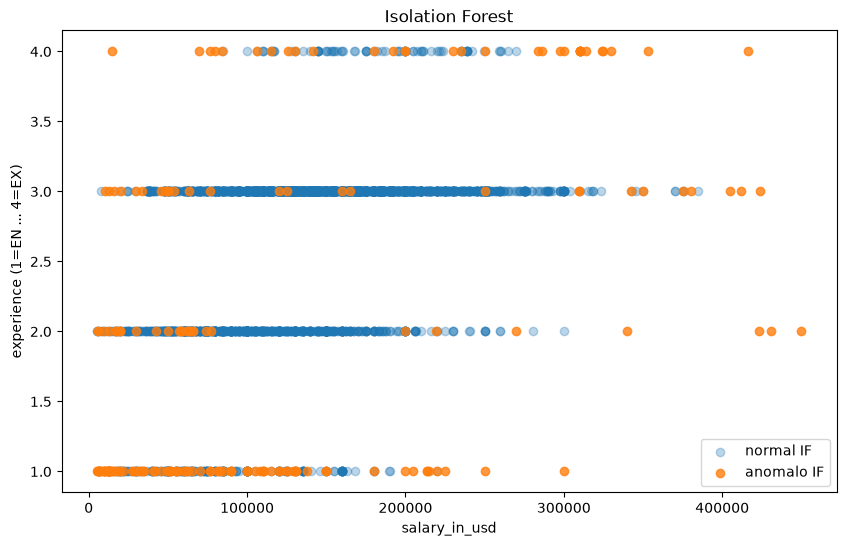

In [161]:
# Aplicamos scatter plot para ver las anomalias

# Scatter plot de salary_in_usd vs remote_ratio
# plt.figure(figsize=(10, 6))
# plt.scatter(df_anom["salary_in_usd"], df_anom["remote_ratio"], c=df_anom["isof_pred"], cmap="viridis")
# plt.colorbar(label="Predicción IF")
# plt.xlabel("Salario en USD")

fig, ax = plt.subplots(figsize=(10, 6))
normales = df_anom[df_anom["isof_pred"] == 1]
anoms = df_anom[df_anom["isof_pred"] == -1]
ax.scatter(normales["salary_in_usd"], normales["experience_ord"], alpha=0.3, label="normal IF")
ax.scatter(anoms["salary_in_usd"], anoms["experience_ord"], alpha=0.8, label="anomalo IF")
ax.set_xlabel("salary_in_usd")
ax.set_ylabel("experience (1=EN ... 4=EX)")
ax.legend()
ax.set_title("Isolation Forest")
plt.show()


b. Identificar al menos un registro marcado como anómalo por alguno de los dos
métodos.

En el grafico se puede ver como hay valores que parecen cuanto mas sospechoso:
- Indice 83, donde un IA Developer en IN tiene una experiencia de EN y un salario de ~300.000
Estimo que en India y/o en cualquier otro lugar un salario de Entry con ese monto NO puede ser real. 

,work_year,experience_level,job_title,salary_in_usd,employee_residence,remote_ratio,company_size,isof_pred,isof_score,lof_pred,lof_score
83,2022,EN,AI Developer,300000,IN,50,L,-1,-0.076096,1,-1.810342


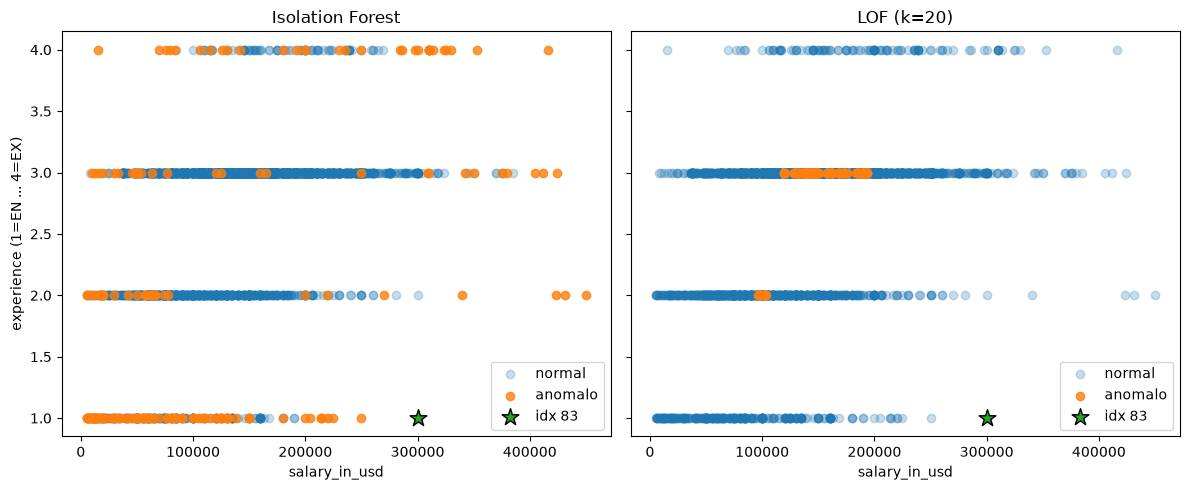

In [163]:
idx = 83
display(df_anom.loc[[idx], cols_ver])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

pares = [
    (axes[0], "isof_pred", "Isolation Forest"),
    (axes[1], "lof_pred", "LOF (k=20)"),
]

for ax, col, titulo in pares:
    normales = df_anom[df_anom[col] == 1]
    anoms = df_anom[df_anom[col] == -1]
    ax.scatter(normales["salary_in_usd"], normales["experience_ord"],
               alpha=0.25, label="normal")
    ax.scatter(anoms["salary_in_usd"], anoms["experience_ord"],
               alpha=0.8, label="anomalo")
    # el registro del b/c/d
    ax.scatter(df_anom.loc[idx, "salary_in_usd"],
               df_anom.loc[idx, "experience_ord"],
               s=160, marker="*", edgecolor="k", label=f"idx {idx}")
    ax.set_xlabel("salary_in_usd")
    ax.set_title(titulo)
    ax.legend()

axes[0].set_ylabel("experience (1=EN ... 4=EX)")
plt.tight_layout()
plt.show()

In [158]:
idx = 83
fila = df_anom.loc[idx]
print("Registro", idx)
print(fila[["experience_level", "salary_in_usd", "remote_ratio",
            "company_size", "employee_residence"]].to_string())
print("\n--- Cada variable por separado ---")
s = df["salary_in_usd"]
q1, q3 = s.quantile(0.25), s.quantile(0.75)
print(f"salary: {fila.salary_in_usd} | mediana {int(s.median())} | p99 {int(s.quantile(0.99))}")
print(f"        IQR fence = {int(q3 + 1.5*(q3-q1))} | >=300k: {(s>=300000).sum()} filas")
print("experience EN:", (df.experience_level=="EN").mean().round(3),
      "| mediana sueldo EN:", int(df.loc[df.experience_level=="EN","salary_in_usd"].median()))
print("remote 50:     ", (df.remote_ratio==50).mean().round(3))
print("company L:     ", (df.company_size=="L").mean().round(3))
print("\n--- Combinacion ---")
print("EN y salary>=300k:", ((df.experience_level=="EN") & (s>=300000)).sum())

Registro 83
experience_level          EN
salary_in_usd         300000
remote_ratio              50
company_size               L
employee_residence        IN

--- Cada variable por separado ---
salary: 300000 | mediana 135000 | p99 309400
        IQR fence = 295000 | >=300k: 53 filas
experience EN: 0.085 | mediana sueldo EN: 70000
remote 50:      0.05
company L:      0.121

--- Combinacion ---
EN y salary>=300k: 1



c. Para ese registro: ¿es un outlier univariado o multivariado? Justificar mirando los
valores reales del registro.

Entiendo que es un outlier **multivariado**
Valores reales del registro 83 en si parecen llamativos en varisa variables: EN, 300.000 USD, remote 50, empresa L, reside en IN.

- `salary_in_usd` es alto (p99 ~309k, apenas arriba del IQR 295k), pero **no es unico**: hay 53 filas con >=300k. Un SE en US con ese sueldo no seria raro.
- `experience_level` = EN aparece en ~8.5% de las filas. No es outlier.
- `remote_ratio` = 50 y `company_size` = L tampoco son extremos por si solos.

Lo llamativo de este registro es que es el unico EN (Entry) con un sueldo de ~300k, cuando una mediana de EN es de ~70k.
Este registro con un IF deberia cortar rapido, y la combinacion de varias columnas parecen explicar el flag.

d. ¿Isolation Forest y LOF coinciden en marcarlo como anómalo? Si no coinciden, ¿a
qué se debe la diferencia (repasar la lógica de cada uno)?

In [159]:
idx = 83
print(df_anom.loc[idx, ["isof_pred", "isof_score", "lof_pred", "lof_score"]])
print("IF -1 = anomalo, 1 = normal")
print("LOF -1 = anomalo, 1 = normal")

isof_pred    -1.000000
isof_score   -0.076096
lof_pred      1.000000
lof_score    -1.810342
Name: 83, dtype: float64
IF -1 = anomalo, 1 = normal
LOF -1 = anomalo, 1 = normal


### Conclusion de IF vs LOF en el registro seleccionado 

**No coinciden.** Isolation Forest lo marca anomalo (`isof_pred = -1`). LOF lo deja como normal (`lof_pred = 1`). En todo el dataset la interseccion fue 0.

**Isolation Forest** (global): arma arboles al azar y mide que tan rapido se **aisla** un punto. Un combo raro (EN + 300k + remote 50 + empresa L) se corta en pocos splits, path corto, score negativo. Por eso el 83 entra en el 5%.

**LOF** (local): compara la **densidad** del punto con la de sus k=20 vecinos. Si alrededor hay otros sueldos altos o hibridos, el 83 no queda tan hueco y su `lof_score` (~-1.8) no alcanza el corte del 5%. Ademas LOF se come el cupo de contamination con filas casi duplicadas (scores de -1e8 en el top), que IF casi no mira.

Concuyendo, el registro 83 es raro en el mapa global, no tanto en su barrio local.



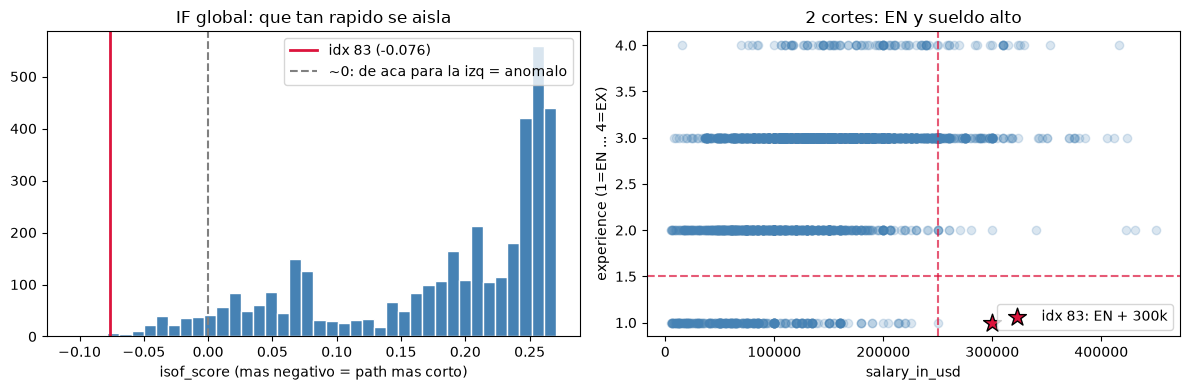

In [165]:
idx = 83
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Score: mas negativo = se aislo en menos splits
ax = axes[0]
ax.hist(df_anom["isof_score"], bins=40, color="steelblue", edgecolor="white")
s83 = df_anom.loc[idx, "isof_score"]
ax.axvline(s83, color="crimson", lw=2, label=f"idx {idx} ({s83:.3f})")
ax.axvline(0, color="gray", ls="--", label="~0: de aca para la izq = anomalo")
ax.set_xlabel("isof_score (mas negativo = path mas corto)")
ax.set_title("IF global: que tan rapido se aisla")
ax.legend()

# 2) El combo: con 2 splits eje alineados el 83 queda casi solo
ax = axes[1]
ax.scatter(df_anom["salary_in_usd"], df_anom["experience_ord"],
           alpha=0.2, c="steelblue")
ax.scatter(df_anom.loc[idx, "salary_in_usd"],
           df_anom.loc[idx, "experience_ord"],
           s=180, marker="*", c="crimson", edgecolor="k", zorder=3,
           label=f"idx {idx}: EN + 300k")
ax.axvline(250000, color="crimson", ls="--", alpha=0.7)
ax.axhline(1.5, color="crimson", ls="--", alpha=0.7)
ax.set_xlabel("salary_in_usd")
ax.set_ylabel("experience (1=EN ... 4=EX)")
ax.set_title("2 cortes: EN y sueldo alto")
ax.legend()

plt.tight_layout()
plt.show()